# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:
Praca z korpusami językowymi

### Cel ćwiczenia:
Celem laboratorium jest zapoznanie się z pojęciem korpusu językowego, nauką wyszukiwania i pobierania gotowych zbiorów danych z platformy HuggingFace Hub oraz przeprowadzenie podstawowych analiz statystycznych tekstu, takich jak badanie prawa Zipfa czy rozkładu długości dokumentów.

### Wykorzystane narzędzia:
* Środowisko: Google Colab / Jupyter Notebook
* Język: Python 3.11
* Biblioteki: datasets, transformers, tokenizers, matplotlib, numpy, pandas, re, stop_words


In [1]:
import re, math, warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer
from stop_words import get_stop_words

wiki = load_dataset('wikimedia/wikipedia', '20231101.pl', split='train', streaming=True)
articles = list(islice(wiki, 200))
texts  = [a['text']  for a in articles]
titles = [a['title'] for a in articles]
print(f"Załadowano {len(texts)} artykułów.")

Załadowano 200 artykułów.


**Odpowiedź na pytanie z zadania 1: Czym różni się korpus językowy od zbioru danych do klasyfikacji?**

Korpus językowy to obszerny i zorganizowany zbiór tekstów (np. artykułów, książek, transkrypcji), który służy jako surowy, empiryczny materiał do badań lingwistycznych i trenowania dużych modeli językowych. Zbiór danych do klasyfikacji to z kolei zestaw tekstów, które zostały dodatkowo przetworzone i opatrzone konkretnymi etykietami docelowymi (np. sentyment: pozytywny/negatywny, kategoria: sport/polityka). Oznacza to, że zbiór klasyfikacyjny jest ukierunkowany na konkretne zadanie przewidujące, natomiast korpus jest źródłem wiedzy ogólnej.

In [ ]:
# zadanie 1
print("Tytuły pierwszych 10 artykułów:")
for i in range(10):
    print(f"{i+1}. {titles[i]}")

print("\n--- Szczegóły dla pierwszych 10 artykułów ---")
for i in range(10):
    text = texts[i]
    words = text.split()
    sentences = re.split(r'(?<=[.!?])\s+', text)
    first_2_sentences = " ".join(sentences[:2])
    
    print(f"Tytuł: {titles[i]} | Liczba słów: {len(words)}")
    print(f"Pierwsze 2 zdania: {first_2_sentences}\n")

lengths = [len(text.split()) for text in texts]
min_idx = lengths.index(min(lengths))
max_idx = lengths.index(max(lengths))

print(f"Najkrótszy artykuł: {titles[min_idx]} ({min(lengths)} słów)")
print(f"Najdłuższy artykuł: {titles[max_idx]} ({max(lengths)} słów)")

Tytuły pierwszych 10 artykułów:
1. AWK
2. Alergologia
3. ASCII
4. Atom
5. Aksjomat
6. Arytmetyka
7. Alkeny
8. ActiveX
9. Interfejs programowania aplikacji
10. AmigaOS

--- Szczegóły dla pierwszych 10 artykułów ---
Tytuł: AWK | Liczba słów: 1661
Pierwsze 2 zdania: AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwanie i przetwarzanie wzorców w plikach lub strumieniach danych. Jest także nazwą programu początkowo dostępnego dla systemów operacyjnych będących pochodnymi UNIX-a, obecnie także na inne platformy.

Tytuł: Alergologia | Liczba słów: 52
Pierwsze 2 zdania: Alergologia – dziedzina medycyny zajmująca się rozpoznawaniem i leczeniem schorzeń alergicznych, czyli takich, u podstaw których stoi zjawisko nadwrażliwości, zwłaszcza inicjowane przez mechanizmy immunologiczne. W Polsce konsultantem krajowym alergologii od 19 lutego 2020 jest prof.

Tytuł: ASCII | Liczba słów: 1545
Pierwsze 2 zdania: ASCII (czyt. aski, skrót od ang.

Tytuł: Atom | Liczba słów: 605

**Odpowiedź na pytanie z pytania 2: Co prawo Zipfa oznacza praktycznie dla budżetu tokenów w LLM?**

Zgodnie z Prawem Zipfa zaledwie garstka słów (np. spójniki, przyimki) pojawia się w tekście z ogromną częstotliwością, natomiast ogromna większość słów (np. terminy specjalistyczne) występuje niezwykle rzadko (tworząc tzw. długi ogon). Dla budżetu tokenów w LLM oznacza to, że model ,,traci'' cenną przestrzeń w oknie kontekstowym na przetwarzanie bardzo powszechnych, mało informatywnych słów. Dodatkowo rzadsze słowa w tokenizatorach opartych o podsłowa (np. BPE) są częściej rozbijane na wiele mniejszych znaków, co błyskawicznie "zjada" limit tokenów w promptach.

Łączna liczba tokenów: 210856
Liczba unikalnych tokenów (types): 47028
TTR (Type-Token Ratio): 0.2230

20 najczęstszych słów:
[('w', 8763), ('i', 5388), ('z', 3677), ('na', 3344), ('się', 2760), ('do', 2543), ('jest', 1556), ('a', 1207), ('przez', 1022), ('nie', 1018), ('roku', 990), ('o', 932), ('od', 928), ('to', 862), ('że', 806), ('oraz', 796), ('po', 734), ('są', 642), ('jako', 618), ('za', 605)]

20 najrzadziej występujących słów:
[('asthma', 1), ('dychawica', 1), ('nadreaktywnością', 1), ('nawracających', 1), ('uczucia', 1), ('ściskania', 1), ('ranem', 1), ('duszność', 1), ('świszczącym', 1), ('oddechem', 1), ('sercowa', 1), ('przewlekłej', 1), ('mnożnik', 1), ('trylionowa', 1), ('najczulsze', 1), ('mierniki', 1), ('dokładnością', 1), ('weights', 1), ('measures', 1), ('bipm', 1)]


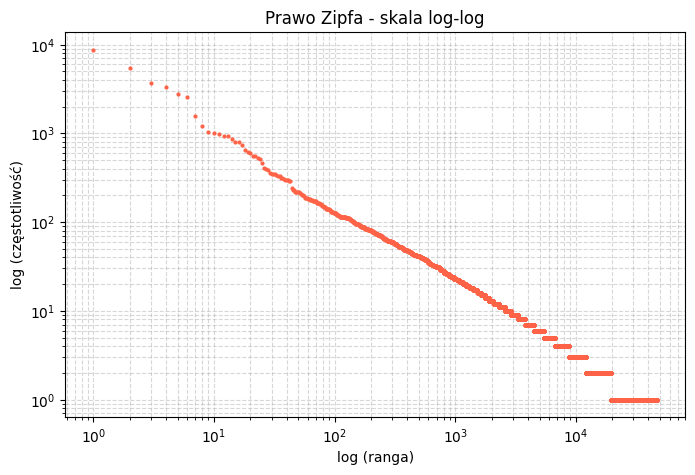

In [ ]:
# zadanie 2
all_texts = " ".join(texts)

tokens = re.findall(r'\b[a-zżźćńółęąś]+\b', all_texts.lower())

total_tokens = len(tokens)
unique_tokens = len(set(tokens))
ttr = unique_tokens / total_tokens if total_tokens > 0 else 0

print(f"Łączna liczba tokenów: {total_tokens}")
print(f"Liczba unikalnych tokenów (types): {unique_tokens}")
print(f"TTR (Type-Token Ratio): {ttr:.4f}")

freq = Counter(tokens)
print("\n20 najczęstszych słów:")
print(freq.most_common(20))

print("\n20 najrzadziej występujących słów:")
print(freq.most_common()[-20:])

counts = [count for word, count in freq.most_common()]
ranks = range(1, len(counts) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranks, counts, marker='o', linestyle='none', markersize=2, color='tomato')
plt.title("Prawo Zipfa - skala log-log")
plt.xlabel("log (ranga)")
plt.ylabel("log (częstotliwość)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**Odpowiedź na pytanie z zadania 3: Ile artykułów wymagałoby obcięcia i czy to problem?**

Zakładając, że jedno słowo w języku polskim to średnio 1.3 tokenu, okno kontekstowe na poziomie 512 tokenów pozwoli modelowi zobaczyć zaledwie około 394 słowa. Jak obliczyliśmy wyżej, spora część artykułów jest dłuższa. Jest to spory problem (szczególnie w zadaniach QA czy generowania streszczeń), ponieważ w procesie ucinania tracimy kluczowy kontekst z końcowych akapitów. Wymusza to stosowanie metod takich jak ,,chunking'' (dzielenie dokumentu na fragmenty).

Min: 10
Max: 12709
Średnia: 1106.4
Mediana: 482.5
Odchylenie standardowe: 1726.3
P95: 4546.8


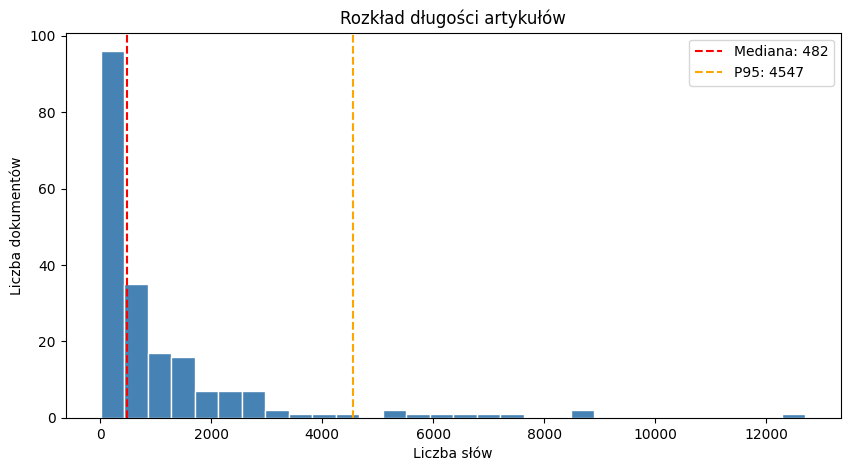


Szacowana liczba artykułów do obcięcia (max_length=512): 111 z 200


In [ ]:
# zadanie 3
lengths = [len(text.split()) for text in texts]

l_min = np.min(lengths)
l_max = np.max(lengths)
l_mean = np.mean(lengths)
l_median = np.median(lengths)
l_std = np.std(lengths)
l_p95 = np.percentile(lengths, 95)

print(f"Min: {l_min}")
print(f"Max: {l_max}")
print(f"Średnia: {l_mean:.1f}")
print(f"Mediana: {l_median:.1f}")
print(f"Odchylenie standardowe: {l_std:.1f}")
print(f"P95: {l_p95:.1f}")

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
plt.axvline(l_median, color='red', linestyle='--', label=f'Mediana: {l_median:.0f}')
plt.axvline(l_p95, color='orange', linestyle='--', label=f'P95: {l_p95:.0f}')
plt.title("Rozkład długości artykułów")
plt.xlabel("Liczba słów")
plt.ylabel("Liczba dokumentów")
plt.legend()
plt.show()

word_limit = 512 / 1.3
truncated = sum(1 for l in lengths if l > word_limit)
print(f"\nSzacowana liczba artykułów do obcięcia (max_length=512): {truncated} z {len(lengths)}")

**Odpowiedź na pytanie z zadania 4: Który model jest bardziej efektywny dla polskiego i dlaczego? Co oznacza słownik podsłów dla jakości modelu?**

HerBERT jest znacznie bardziej ,,efektywny'' dla języka polskiego. Został on wytrenowany dedykowanie na polskich korpusach, przez co lepiej radzi sobie ze złożoną polską morfologią. Wielojęzyczny mBERT musi dzielić swój słownik na ponad 100 języków, dlatego też polskie słowa (szczególnie te długie lub odmieniane) tnie na małe, nieoptymalne sub-tokeny. Większy, wyspecjalizowany słownik podsłów znacząco poprawia jakość modelu – oszczędza cenne miejsce w kontekście wejściowym i ułatwia modelowi zrozumienie wagi semantycznej poszczególnych fraz.


--- Z1 ---
Tekst: AWK – interpretowany język programowania, którego ...
HerBERT (26): ['AW', 'K</w>', '–</w>', 'interpre', 'towany</w>', 'język</w>', 'programowania</w>', ',</w>', 'którego</w>', 'główną</w>', 'funkcją</w>', 'jest</w>', 'wyszuki', 'wanie</w>', 'i</w>', 'przetwarz', 'anie</w>', 'wzorców</w>', 'w</w>', 'pli', 'kach</w>', 'lub</w>', 'stru', 'mieniach</w>', 'danych</w>', '.</w>']
mBERT (40): ['A', '##W', '##K', '[UNK]', 'inter', '##pret', '##owany', 'język', 'program', '##owania', ',', 'którego', 'g', '##łówną', 'funk', '##cją', 'jest', 'w', '##ys', '##zuki', '##wanie', 'i', 'pr', '##zet', '##war', '##zanie', 'w', '##zor', '##ców', 'w', 'pl', '##ika', '##ch', 'lub', 'str', '##umi', '##enia', '##ch', 'danych', '.']

--- Z2 ---
Tekst: Jest także nazwą programu początkowo dostępnego dl...
HerBERT (24): ['Jest</w>', 'także</w>', 'nazwą</w>', 'programu</w>', 'początkowo</w>', 'dostęp', 'nego</w>', 'dla</w>', 'systemów</w>', 'operacyjnych</w>', 'będących</w>', 'pochod', 'nymi</w

,zdanie,herbert_n,mbert_n,roznica
0,Z1,26,40,14
1,Z2,24,30,6
2,Z3,23,34,11
3,Z4,12,17,5
4,Z5,16,14,-2
5,Z6,27,36,9
6,Z7,29,25,-4
7,Z8,50,55,5
8,Z9,48,59,11
9,Z10,17,29,12


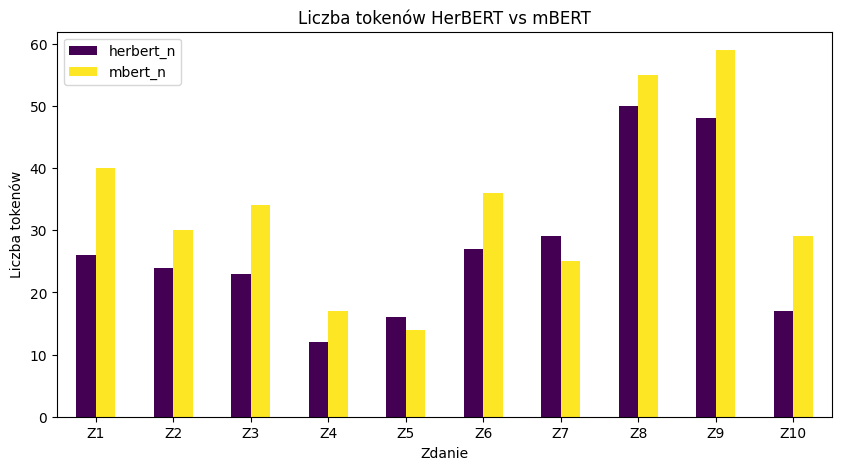

In [ ]:
# zadanie 4
tokenizer_herbert = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")
tokenizer_mbert = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

text_0 = texts[0]

all_sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text_0) if s.strip()]

sentences = all_sentences[:10]

data = []
for i, sent in enumerate(sentences):
    tok_herbert = tokenizer_herbert.tokenize(sent)
    tok_mbert = tokenizer_mbert.tokenize(sent)
    
    n_herbert = len(tok_herbert)
    n_mbert = len(tok_mbert)
    
    data.append({
        "zdanie": f"Z{i+1}",
        "tekst": sent[:50] + "...",
        "herbert_n": n_herbert,
        "mbert_n": n_mbert,
        "roznica": n_mbert - n_herbert,
        "tok_herbert": tok_herbert,
        "tok_mbert": tok_mbert
    })

df = pd.DataFrame(data)

for idx, row in df.iterrows():
    print(f"\n--- {row['zdanie']} ---")
    print(f"Tekst: {row['tekst']}")
    print(f"HerBERT ({row['herbert_n']}): {row['tok_herbert']}")
    print(f"mBERT ({row['mbert_n']}): {row['tok_mbert']}")

display(df[['zdanie', 'herbert_n', 'mbert_n', 'roznica']])

df.plot(x="zdanie", y=["herbert_n", "mbert_n"], kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Liczba tokenów HerBERT vs mBERT")
plt.xlabel("Zdanie")
plt.ylabel("Liczba tokenów")
plt.xticks(rotation=0)
plt.show()

**Odpowiedź na pytanie z zadania 5: Jak stop-słowa wpływają na sensowność kolokacji? Kiedy je usuwać, a kiedy zostawić?**

Usunięcie stopwords (np. ,,w'', ,,i'', ,,na'') sprawia, że zidentyfikowane kolokacje nabierają ogromnego sensu i odsłaniają rzeczywistą treść dokumentów (np. nazwy własne czy powszechne wyrażenia jak ,,stany zjednoczone'').
Stopwords warto usuwać przy budowie indeksów słów kluczowych czy w modelu bag-of-words (np. TF-IDF), gdzie szukamy najważniejszej tematyki. Należy je jednak zostawiać dla zadań takich jak dependency parsing (analiza zależności w zdaniu) i przy trenowaniu Modeli Językowych (LLM/Transformerów), ponieważ to właśnie przyimki i spójniki spajają relacje składniowe tekstu i wpływają na wektory atencji.

In [ ]:
# zadanie 5
def get_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

all_texts = " ".join(texts)
tokens = re.findall(r'\b[a-zżźćńółęąś]+\b', all_texts.lower())

bigrams = get_ngrams(tokens, 2)
freq_bigrams = Counter(bigrams)

print("--- Część A: Top 20 bigramów ---")
for bg, count in freq_bigrams.most_common(20):
    print(f"{bg}: {count}")

trigrams = get_ngrams(tokens, 3)
freq_trigrams = Counter(trigrams)

print("\n--- Część B: Top 15 trigramów ---")
for tg, count in freq_trigrams.most_common(15):
    print(f"{tg}: {count}")

stopwords_pl = set(get_stop_words('pl'))
tokens_filtered = [word for word in tokens if word not in stopwords_pl]

bigrams_filtered = get_ngrams(tokens_filtered, 2)
freq_bigrams_filtered = Counter(bigrams_filtered)

print("\n--- Część C: Top 20 bigramów bez stopwords ---")
for bg, count in freq_bigrams_filtered.most_common(20):
    print(f"{bg}: {count}")

--- Część A: Top 20 bigramów ---
('w', 'roku'): 535
('się', 'w'): 272
('w', 'tym'): 272
('się', 'na'): 203
('się', 'z'): 191
('w', 'latach'): 171
('m', 'in'): 164
('się', 'do'): 150
('a', 'także'): 133
('n', 'e'): 130
('względu', 'na'): 124
('ze', 'względu'): 114
('w', 'r'): 113
('jak', 'i'): 105
('wraz', 'z'): 99
('zobacz', 'też'): 97
('p', 'n'): 97
('na', 'świecie'): 92
('xx', 'wieku'): 92
('nie', 'jest'): 89

--- Część B: Top 15 trigramów ---
('ze', 'względu', 'na'): 113
('p', 'n', 'e'): 97
('w', 'tym', 'samym'): 52
('przypisy', 'linki', 'zewnętrzne'): 43
('w', 'roku', 'w'): 42
('po', 'raz', 'pierwszy'): 37
('w', 'związku', 'z'): 35
('m', 'n', 'p'): 34
('n', 'p', 'm'): 34
('w', 'ten', 'sposób'): 33
('w', 'stanach', 'zjednoczonych'): 32
('ii', 'wojny', 'światowej'): 28
('tym', 'samym', 'roku'): 27
('jest', 'jednym', 'z'): 27
('co', 'do', 'wielkości'): 26

--- Część C: Top 20 bigramów bez stopwords ---
('m', 'in'): 164
('n', 'e'): 131
('p', 'n'): 98
('xx', 'wieku'): 92
('linki', 'zewn

### Wnioski

Realizacja ćwiczenia pozwoliła na praktyczne zapoznanie się z rolą korpusów językowych jako fundamentu współczesnego przetwarzania języka naturalnego (NLP). Na podstawie przeprowadzonych zadań sformułowano następujące wnioski:

1. **Reprezentatywność i statystyka:** Analiza statystyczna korpusu Wikipedii potwierdziła występowanie prawa Zipfa w rzeczywistych danych tekstowych. Dominacja niewielkiej liczby słów funkcyjnych nad rzadkimi słowami merytorycznymi ma kluczowe znaczenie dla zarządzania budżetem tokenów w modelach językowych.

2. **Efektywność tokenizacji:** Porównanie tokenizatorów wykazało znaczną przewagę modelu dedykowanego dla języka polskiego (HerBERT) nad modelem wielojęzycznym (mBERT). Model wyspecjalizowany generuje krótsze sekwencje tokenów dla tych samych treści, co pozwala na lepsze wykorzystanie okna kontekstowego i skuteczniejszą obsługę bogatej polskiej fleksji.

3. **Wpływ preprocessingu:** Eksperymenty z n-gramami pokazały, że usuwanie stop-słów jest niezbędne w zadaniach ekstrakcji wiedzy i kolokacji merytorycznych, jednak w zadaniach czysto lingwistycznych (jak analiza składniowa) ich zachowanie jest kluczowe dla spójności strukturalnej tekstu.

4. **Ograniczenia techniczne:** Analiza rozkładu długości dokumentów uświadomiła wagę parametru `max_length`. Konieczność obcinania tekstów (truncation) w modelach typu Transformer stanowi wyzwanie, które wymaga stosowania odpowiednich strategii podziału tekstu, aby nie utracić istotnych informacji zawartych w końcowych fragmentach dokumentów.

Podsumowując, dobór odpowiedniego korpusu oraz optymalna strategia tokenizacji i filtrowania danych są kluczowymi czynnikami wpływającymi na wydajność i jakość końcowych modeli uczenia maszynowego w zadaniach NLP.